# Loan Default Prediction using Machine Learning

Problem Statement

Objective

Banks provide loans to thousands of customers every year. Some customers repay their loans on time, while others fail to repay them (loan default).
The goal of this project is to build a Machine Learning model that predicts whether a customer is likely to default before approving the loan.

This prediction helps banks:

->Reduce financial losses

->Approve loans for trustworthy customers

->Reject risky applications

->Improve decision-making

# Dataset Information

Dataset Name:
Loan Default Prediction Dataset

Dataset Source:
Kaggle

Dataset Type:
Structured Tabular Data

Prediction Type:
Binary Classification

Target Variable:
Loan Status / Default

# Dataset Information


Dataset Type	-       CSV

Rows	   -           255347

Columns	    -          18 

Missing Values         -

Duplicate Values	   -

Target Variable	  -   Default

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Loan_default.csv")

In [3]:
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [6]:
df.shape

(255347, 18)

In [7]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [8]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [9]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [10]:
df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [11]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

In [12]:
df['Education'].value_counts()

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

<Axes: xlabel='HasMortgage', ylabel='count'>

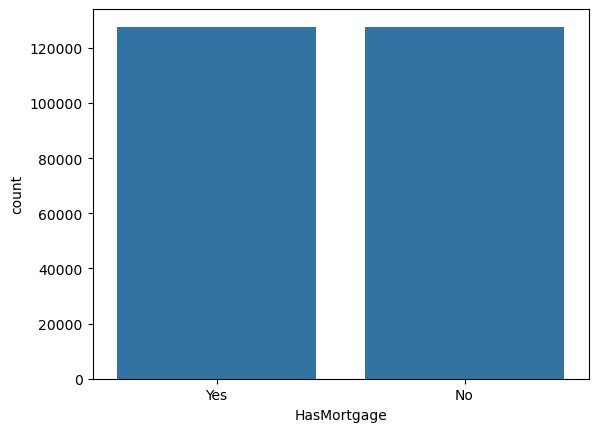

In [13]:
sns.countplot(x = df['HasMortgage'])

<Axes: xlabel='HasDependents', ylabel='count'>

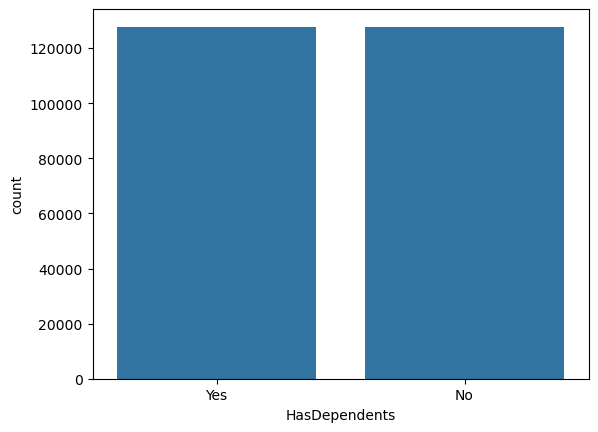

In [14]:
sns.countplot(x = df['HasDependents'])

<Axes: xlabel='HasCoSigner', ylabel='count'>

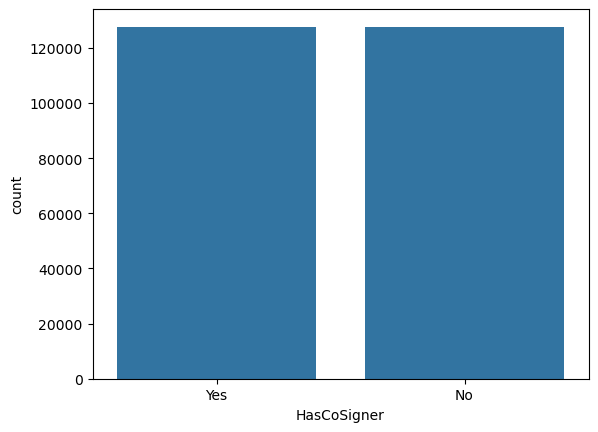

In [15]:
sns.countplot(x = df['HasCoSigner'])

In [16]:
df['LoanPurpose'].value_counts()

LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

In [17]:

df['EmploymentType'].value_counts()

EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

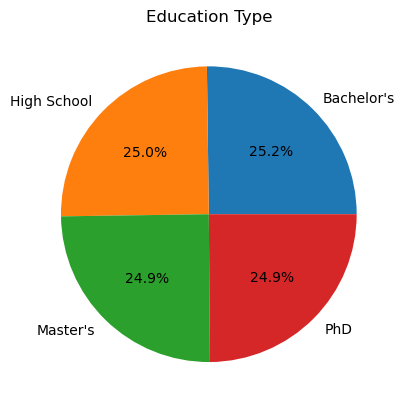

In [18]:
df["Education"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Education Type")
plt.ylabel("")

plt.show()

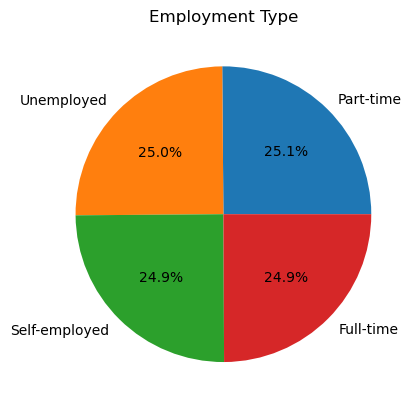

In [19]:
df["EmploymentType"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Employment Type")
plt.ylabel("")

plt.show()

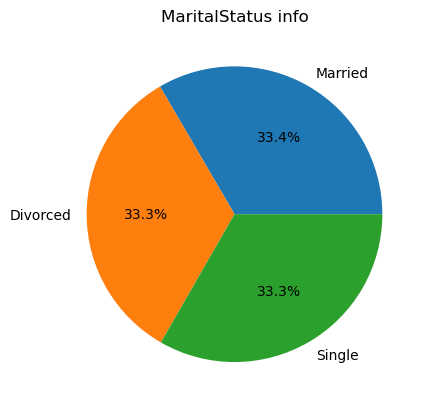

In [20]:
df["MaritalStatus"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("MaritalStatus info")
plt.ylabel("")

plt.show()

# Data Cleaning and preprocessing

In [21]:
df_cleaned = df.copy()

In [22]:
df_cleaned.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [23]:
df_cleaned.drop_duplicates(inplace = True)

In [24]:
df_cleaned.shape

(255347, 18)

In [25]:
df_cleaned.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [26]:
df_cleaned.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [27]:
df_cleaned['Education'].unique()

array(["Bachelor's", "Master's", 'High School', 'PhD'], dtype=object)

In [28]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['Education'],drop_first = False)

In [29]:
df_cleaned.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Education_Bachelor's,Education_High School,Education_Master's,Education_PhD
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,Divorced,Yes,Yes,Other,Yes,0,True,False,False,False
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,Married,No,No,Other,Yes,0,False,False,True,False
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,Divorced,Yes,Yes,Auto,No,1,False,False,True,False
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,Married,No,No,Business,No,0,False,True,False,False
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,Divorced,No,Yes,Auto,No,0,True,False,False,False


In [30]:
df_cleaned['HasMortgage'].unique()

array(['Yes', 'No'], dtype=object)

In [31]:
df_cleaned['HasMortgage'] = df_cleaned['HasMortgage'].map({"Yes" : 1 , "No" : 0})

In [32]:
df_cleaned.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Education_Bachelor's,Education_High School,Education_Master's,Education_PhD
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,Divorced,1,Yes,Other,Yes,0,True,False,False,False
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,Married,0,No,Other,Yes,0,False,False,True,False
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,Divorced,1,Yes,Auto,No,1,False,False,True,False
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,Married,0,No,Business,No,0,False,True,False,False
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,Divorced,0,Yes,Auto,No,0,True,False,False,False


In [33]:
df_cleaned['HasDependents'] = df_cleaned['HasDependents'].map({"Yes" : 1 , "No" : 0})
df_cleaned['HasCoSigner'] = df_cleaned['HasCoSigner'].map({"Yes" : 1 , "No" : 0})


In [34]:
df_cleaned.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Education_Bachelor's,Education_High School,Education_Master's,Education_PhD
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,Divorced,1,1,Other,1,0,True,False,False,False
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,Married,0,0,Other,1,0,False,False,True,False
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,Divorced,1,1,Auto,0,1,False,False,True,False
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,Married,0,0,Business,0,0,False,True,False,False
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,Divorced,0,1,Auto,0,0,True,False,False,False


In [35]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['EmploymentType'],drop_first = False)

In [36]:
df_cleaned.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,HasCoSigner,Default,Education_Bachelor's,Education_High School,Education_Master's,Education_PhD,EmploymentType_Full-time,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,1,0,True,False,False,False,True,False,False,False
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,1,0,False,False,True,False,True,False,False,False
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,0,1,False,False,True,False,False,False,False,True
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,0,0,False,True,False,False,True,False,False,False
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,0,0,True,False,False,False,False,False,False,True


In [37]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['LoanPurpose'],drop_first = False)


In [38]:
df_cleaned.dtypes

LoanID                           object
Age                               int64
Income                            int64
LoanAmount                        int64
CreditScore                       int64
MonthsEmployed                    int64
NumCreditLines                    int64
InterestRate                    float64
LoanTerm                          int64
DTIRatio                        float64
MaritalStatus                    object
HasMortgage                       int64
HasDependents                     int64
HasCoSigner                       int64
Default                           int64
Education_Bachelor's               bool
Education_High School              bool
Education_Master's                 bool
Education_PhD                      bool
EmploymentType_Full-time           bool
EmploymentType_Part-time           bool
EmploymentType_Self-employed       bool
EmploymentType_Unemployed          bool
LoanPurpose_Auto                   bool
LoanPurpose_Business               bool


In [39]:
df_cleaned['MaritalStatus'].unique()

array(['Divorced', 'Married', 'Single'], dtype=object)

In [40]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['MaritalStatus'],drop_first = False)


In [41]:
df_cleaned.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,EmploymentType_Self-employed,EmploymentType_Unemployed,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,False,False,False,False,False,False,True,True,False,False
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,False,False,False,False,False,False,True,False,True,False
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,False,True,True,False,False,False,False,True,False,False
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,False,False,False,True,False,False,False,False,True,False
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,False,True,True,False,False,False,False,True,False,False


In [42]:
df_cleaned.dtypes

LoanID                           object
Age                               int64
Income                            int64
LoanAmount                        int64
CreditScore                       int64
MonthsEmployed                    int64
NumCreditLines                    int64
InterestRate                    float64
LoanTerm                          int64
DTIRatio                        float64
HasMortgage                       int64
HasDependents                     int64
HasCoSigner                       int64
Default                           int64
Education_Bachelor's               bool
Education_High School              bool
Education_Master's                 bool
Education_PhD                      bool
EmploymentType_Full-time           bool
EmploymentType_Part-time           bool
EmploymentType_Self-employed       bool
EmploymentType_Unemployed          bool
LoanPurpose_Auto                   bool
LoanPurpose_Business               bool
LoanPurpose_Education              bool


In [43]:
df_cleaned.columns = df_cleaned.columns.str.strip().str.lower().str.replace(' ', '_') 

In [44]:
df_cleaned.dtypes

loanid                           object
age                               int64
income                            int64
loanamount                        int64
creditscore                       int64
monthsemployed                    int64
numcreditlines                    int64
interestrate                    float64
loanterm                          int64
dtiratio                        float64
hasmortgage                       int64
hasdependents                     int64
hascosigner                       int64
default                           int64
education_bachelor's               bool
education_high_school              bool
education_master's                 bool
education_phd                      bool
employmenttype_full-time           bool
employmenttype_part-time           bool
employmenttype_self-employed       bool
employmenttype_unemployed          bool
loanpurpose_auto                   bool
loanpurpose_business               bool
loanpurpose_education              bool


In [45]:
df_cleaned['loanid'].unique()

array(['I38PQUQS96', 'HPSK72WA7R', 'C1OZ6DPJ8Y', ..., 'XQK1UUUNGP',
       'JAO28CPL4H', 'ZTH91CGL0B'], dtype=object)

In [46]:
df_cleaned.drop(columns=['loanid'], inplace=True)

In [47]:
df_cleaned.dtypes

age                               int64
income                            int64
loanamount                        int64
creditscore                       int64
monthsemployed                    int64
numcreditlines                    int64
interestrate                    float64
loanterm                          int64
dtiratio                        float64
hasmortgage                       int64
hasdependents                     int64
hascosigner                       int64
default                           int64
education_bachelor's               bool
education_high_school              bool
education_master's                 bool
education_phd                      bool
employmenttype_full-time           bool
employmenttype_part-time           bool
employmenttype_self-employed       bool
employmenttype_unemployed          bool
loanpurpose_auto                   bool
loanpurpose_business               bool
loanpurpose_education              bool
loanpurpose_home                   bool


In [48]:
bool_column = df_cleaned.select_dtypes(include='bool').columns
df_cleaned[bool_column] = df_cleaned[bool_column].astype(int)

In [49]:
df_cleaned.head()

,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,hasmortgage,...,employmenttype_self-employed,employmenttype_unemployed,loanpurpose_auto,loanpurpose_business,loanpurpose_education,loanpurpose_home,loanpurpose_other,maritalstatus_divorced,maritalstatus_married,maritalstatus_single
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,0,0,0,0,0,0,1,1,0,0
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,0,0,0,0,0,1,0,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,0,1,1,0,0,0,0,1,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,0,0,1,0,0,0,0,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,0,1,1,0,0,0,0,1,0,0


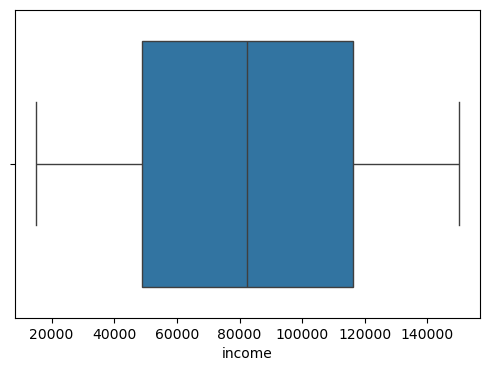

In [50]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_cleaned["income"])
plt.show()

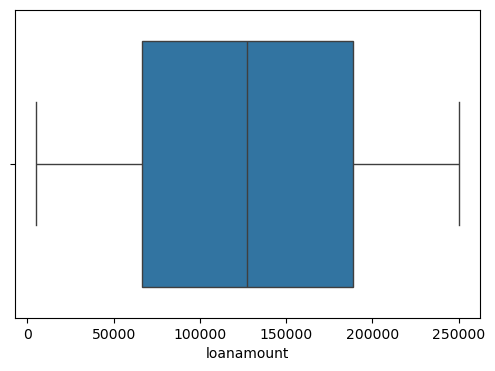

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_cleaned["loanamount"])
plt.show()

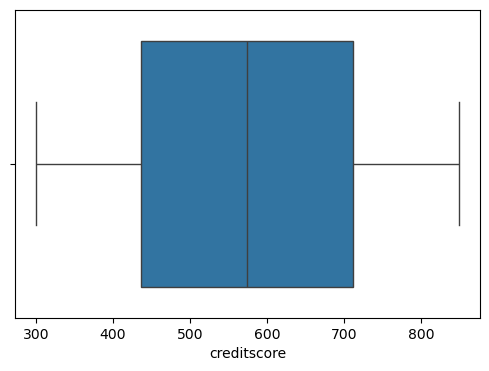

In [52]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_cleaned["creditscore"])
plt.show()

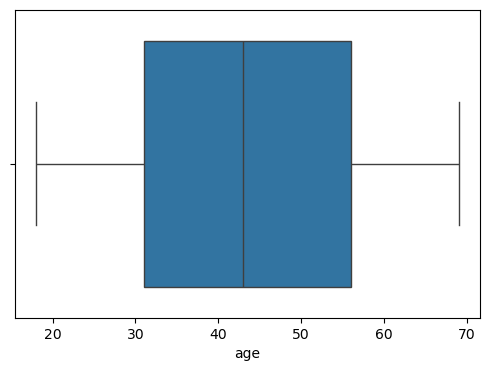

In [53]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_cleaned["age"])
plt.show()

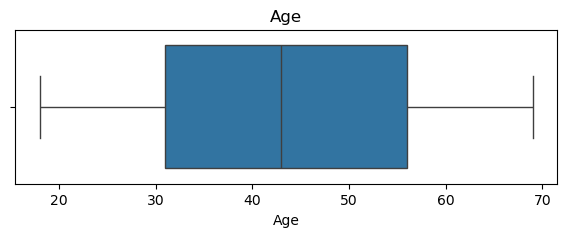

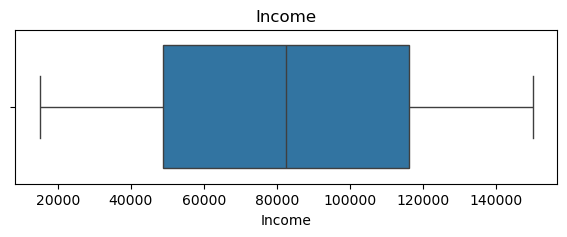

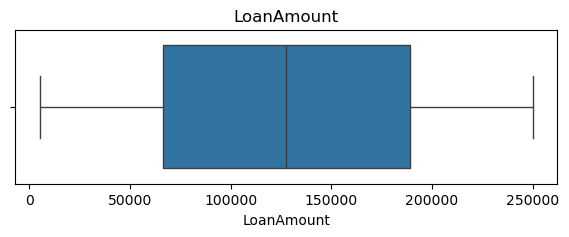

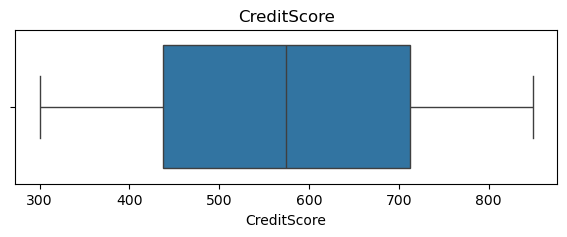

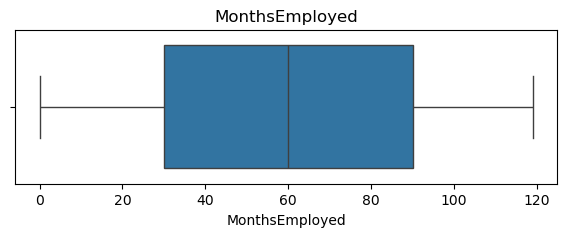

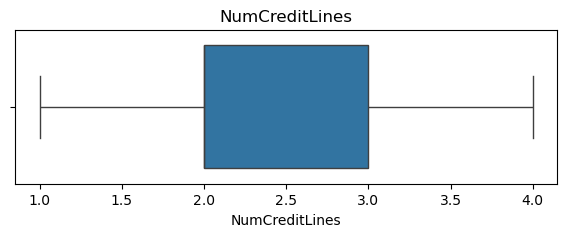

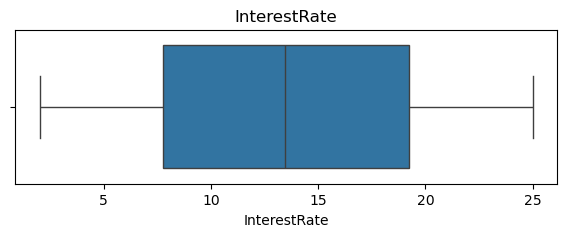

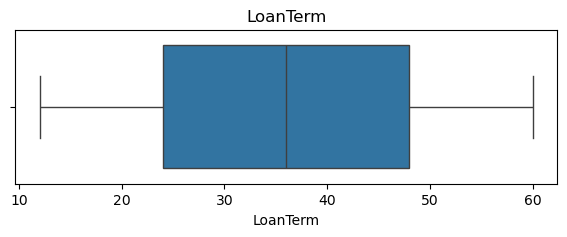

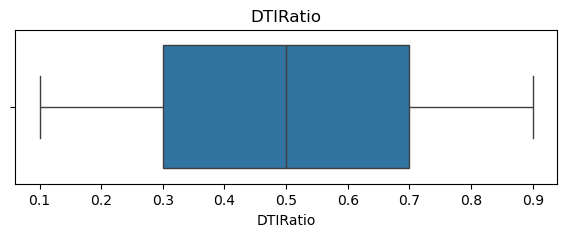

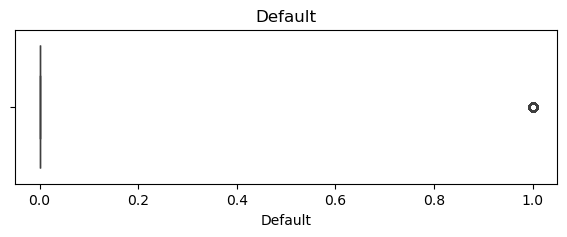

In [54]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(7,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# train_test_split

In [55]:
df_cleaned.columns

Index(['age', 'income', 'loanamount', 'creditscore', 'monthsemployed',
       'numcreditlines', 'interestrate', 'loanterm', 'dtiratio', 'hasmortgage',
       'hasdependents', 'hascosigner', 'default', 'education_bachelor's',
       'education_high_school', 'education_master's', 'education_phd',
       'employmenttype_full-time', 'employmenttype_part-time',
       'employmenttype_self-employed', 'employmenttype_unemployed',
       'loanpurpose_auto', 'loanpurpose_business', 'loanpurpose_education',
       'loanpurpose_home', 'loanpurpose_other', 'maritalstatus_divorced',
       'maritalstatus_married', 'maritalstatus_single'],
      dtype='object')

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_cleaned.drop('default', axis=1)
y = df_cleaned['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

cols = [
    'age', 'income', 'loanamount', 'creditscore', 'monthsemployed',
       'numcreditlines', 'interestrate', 'loanterm', 'dtiratio'
]

scaler = StandardScaler()

X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [58]:
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score

In [60]:
train_score = model.score(X_train, y_train)
print("Training Accuracy:", train_score)

Training Accuracy: 0.8849601276697817


In [61]:
test_score = model.score(X_test, y_test)
print("Testing Accuracy:", test_score)

Testing Accuracy: 0.8858037987076561


In [62]:
print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)

Training Accuracy: 0.8849601276697817
Testing Accuracy: 0.8858037987076561


## Additional Classification Models (Added)

In [63]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [64]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_acc)

KNN Accuracy : 0.8753084002349716


In [65]:
nb = GaussianNB()

nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy :", nb_acc)

Naive Bayes Accuracy : 0.8858037987076561


In [66]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", dt_acc)

Decision Tree Accuracy : 0.8006070099862933



 Logistic Regression


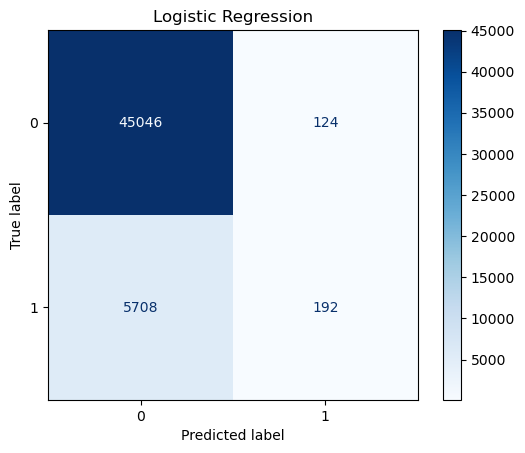


 KNN


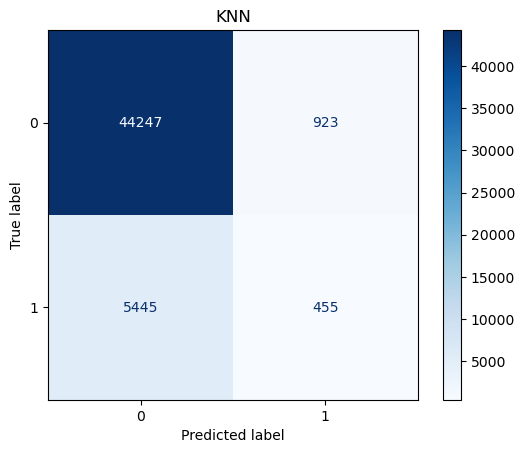


 Naive Bayes


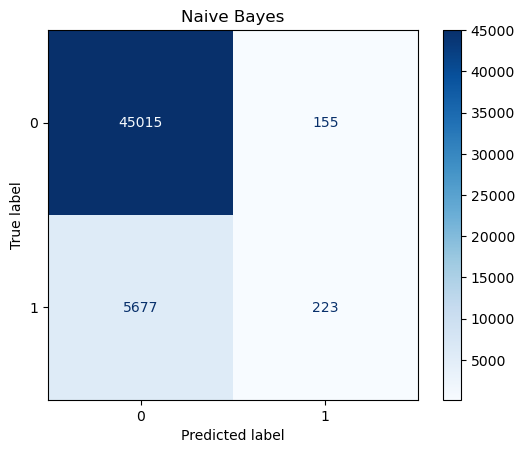


 Decision Tree


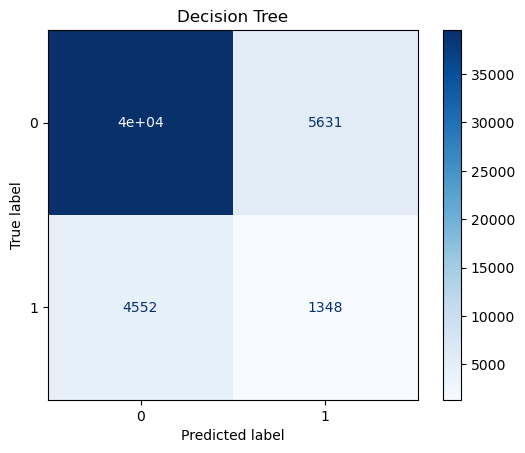

In [67]:
models = {
    "Logistic Regression": y_pred,
    "KNN": knn_pred,
    "Naive Bayes": nb_pred,
    "Decision Tree": dt_pred
}

for name, pred in models.items():
    print("\n", name)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(name)
    plt.show()

In [68]:
print("Model Accuracy")
print("Logistic Regression :", accuracy_score(y_test, y_pred))
print("KNN                 :", knn_acc)
print("Naive Bayes         :", nb_acc)
print("Decision Tree       :", dt_acc)

Model Accuracy
Logistic Regression : 0.8858037987076561
KNN                 : 0.8753084002349716
Naive Bayes         : 0.8858037987076561
Decision Tree       : 0.8006070099862933


# Advanced Modeling: Ensembles, Cross-Validation, Model Comparison & Hyperparameter Tuning

This section builds on the models above without changing them. We add:- Advanced models (Random Forest, Gradient Boosting)- K-Fold Cross-Validation for stability checks- A side-by-side comparison of all models on validation metrics- Hyperparameter tuning (GridSearchCV) on the best-performing model

## 1. Advanced Models

In [69]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_acc)

Random Forest Accuracy : 0.8868807519091443


In [70]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy :", gb_acc)

Gradient Boosting Accuracy : 0.8873311141570394


## 2. Cross-Validation (Model Stability)

5-fold cross-validation is used to check that each model's performance is stable and not dependent on a single train/test split. We report the mean accuracy and standard deviation for every model, including the ones defined earlier in the notebook.

In [71]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Logistic Regression": model,
    "KNN": knn,
    "Naive Bayes": nb,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

cv_results = {}

for name, m in cv_models.items():
    scores = cross_val_score(m, X, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:20s} Mean Accuracy: {scores.mean():.4f}  Std Dev: {scores.std():.4f}")

Logistic Regression  Mean Accuracy: 0.8842  Std Dev: 0.0002
KNN                  Mean Accuracy: 0.8736  Std Dev: 0.0007
Naive Bayes          Mean Accuracy: 0.8843  Std Dev: 0.0002
Decision Tree        Mean Accuracy: 0.8013  Std Dev: 0.0013
Random Forest        Mean Accuracy: 0.8855  Std Dev: 0.0003
Gradient Boosting    Mean Accuracy: 0.8863  Std Dev: 0.0003


In [72]:
cv_summary_df = pd.DataFrame({
    name: [scores.mean(), scores.std()] for name, scores in cv_results.items()
}, index=["Mean Accuracy", "Std Dev"]).T.sort_values("Mean Accuracy", ascending=False)

cv_summary_df

,Mean Accuracy,Std Dev
Gradient Boosting,0.886261,0.000330
Random Forest,0.885544,0.000321
Naive Bayes,0.884346,0.000161
Logistic Regression,0.884197,0.000202
KNN,0.873635,0.000679
Decision Tree,0.801349,0.001259


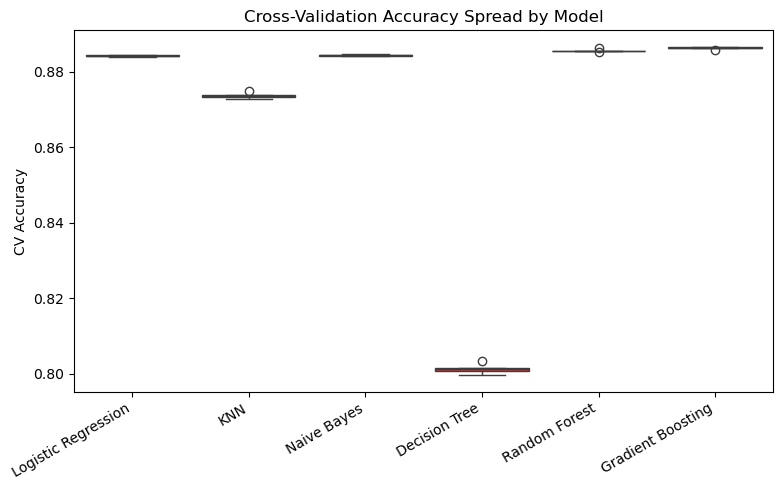

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[cv_results[n] for n in cv_results], orient='v')
plt.xticks(range(len(cv_results)), list(cv_results.keys()), rotation=30, ha='right')
plt.ylabel("CV Accuracy")
plt.title("Cross-Validation Accuracy Spread by Model")
plt.tight_layout()
plt.show()

## 3. Model Comparison on Validation Metrics

Accuracy alone can be misleading on imbalanced data (loan default is usually imbalanced). We compare all models on Precision, Recall, F1-score and ROC-AUC using the held-out test set, alongside the cross-validation mean accuracy computed above.

In [74]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

pred_map = {
    "Logistic Regression": (model, y_pred),
    "KNN": (knn, knn_pred),
    "Naive Bayes": (nb, nb_pred),
    "Decision Tree": (dt, dt_pred),
    "Random Forest": (rf, rf_pred),
    "Gradient Boosting": (gb, gb_pred)
}

comparison_rows = []

for name, (m, pred) in pred_map.items():
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0),
        "CV Mean Accuracy": cv_results[name].mean(),
        "CV Std Dev": cv_results[name].std()
    }
    if hasattr(m, "predict_proba"):
        proba = m.predict_proba(X_test)[:, 1]
        row["ROC-AUC"] = roc_auc_score(y_test, proba)
    else:
        row["ROC-AUC"] = None
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("F1-Score", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,CV Mean Accuracy,CV Std Dev,ROC-AUC
0,Decision Tree,0.800607,0.193151,0.228475,0.209333,0.801349,0.001259,0.551906
1,KNN,0.875308,0.330189,0.077119,0.125034,0.873635,0.000679,0.622496
2,Gradient Boosting,0.887331,0.657328,0.051695,0.095852,0.886261,0.000330,0.757207
3,Naive Bayes,0.885804,0.589947,0.037797,0.071042,0.884346,0.000161,0.745627
4,Random Forest,0.886881,0.715789,0.034576,0.065966,0.885544,0.000321,0.740091
5,Logistic Regression,0.885804,0.607595,0.032542,0.061776,0.884197,0.000202,0.752527


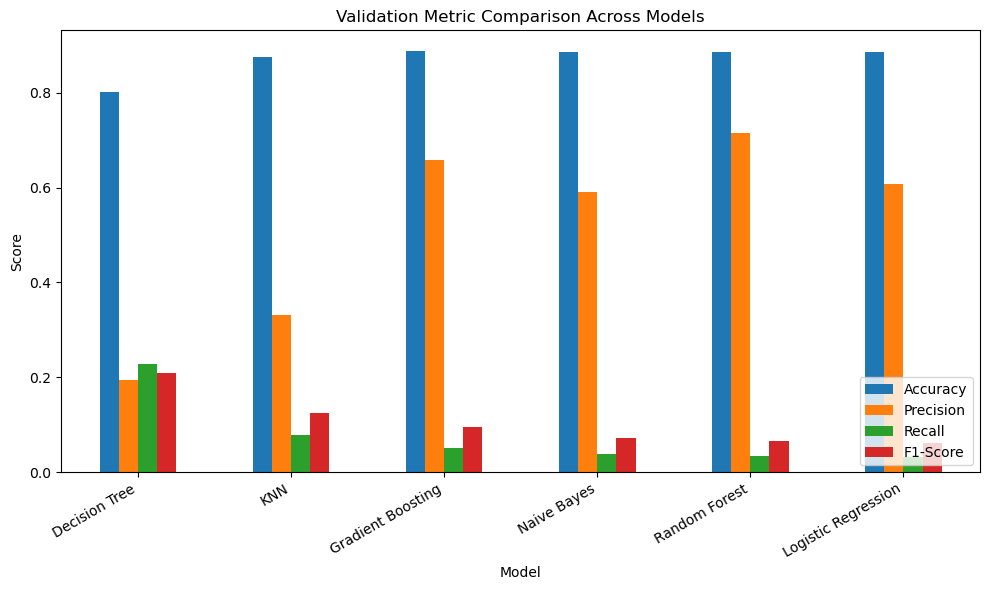

In [75]:
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Validation Metric Comparison Across Models")
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning

We tune the strongest model from the comparison above (Random Forest) using GridSearchCV with 5-fold cross-validation, optimizing for F1-score since default prediction is typically an imbalanced classification problem.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-Score:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [ ]:
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

print("Tuned Random Forest - Test Set Performance")
print("Accuracy :", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred, zero_division=0))
print("Recall   :", recall_score(y_test, best_rf_pred, zero_division=0))
print("F1-Score :", f1_score(y_test, best_rf_pred, zero_division=0))

In [ ]:
cm = confusion_matrix(y_test, best_rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

## 5. Final Summary

In [ ]:
final_summary = comparison_df.copy()

tuned_row = {
    "Model": "Random Forest (Tuned)",
    "Accuracy": accuracy_score(y_test, best_rf_pred),
    "Precision": precision_score(y_test, best_rf_pred, zero_division=0),
    "Recall": recall_score(y_test, best_rf_pred, zero_division=0),
    "F1-Score": f1_score(y_test, best_rf_pred, zero_division=0),
    "CV Mean Accuracy": grid_search.best_score_,
    "CV Std Dev": None,
    "ROC-AUC": roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
}

final_summary = pd.concat([final_summary, pd.DataFrame([tuned_row])], ignore_index=True)
final_summary.sort_values("F1-Score", ascending=False).reset_index(drop=True)